# Dog vs Cat Classifier (NumPy Neural Network)

A simple 1-hidden-layer neural network built **from scratch using only NumPy** (no TensorFlow/PyTorch) to classify images as dog or cat.

**Pipeline:** load images from Google Drive → preprocess & flatten → normalize → train/test split → train with gradient descent → evaluate accuracy → run predictions on new images.


## 1. Setup: Mount Google Drive & Inspect Data

In [ ]:
import os
print(os.getcwd())
print(os.listdir())

/content
['.config', 'dogs_folder', 'cats_folder', 'drive', 'sample_data']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
os.listdir('/content/drive/MyDrive')

['Parijat Ghosh rough.pdf',
 'parijat eng ppt.docx',
 'COMPLEX NUMBERS_copy.pdf',
 'DOC-20230817-WA0008._copy.pdf',
 'binomial .pdf',
 'fluids.pdf',
 'fluids 2.pdf',
 'thermo 1.pdf',
 'Untitled Jam (3).pdf',
 'rotation .pdf',
 'Untitled Jam (2).pdf',
 'Untitled Jam (1).pdf',
 'Untitled Jam.pdf',
 'Document.pdf',
 'Document 2.pdf',
 'FTRE_Class 11_Syllabus.jpeg',
 'GOC_worksheet-2_copy.pdf',
 'Maths sougata sir',
 'Father_to_Son.docx',
 'The_Adventure.docx',
 'Laburnum_Top.docx',
 'Grammar_Practice_Exercises.docx',
 'DC Pandey Electricity And Magnetism (crackjee.xyz).pdf',
 'functions (till Q13).pdf',
 'Notice___Nursery_to_Class_12.pdf',
 'HOLIDAY_HOMEWORK_CLASS_12_SCIENCE_2024-25_(1).pdf',
 'Bookshop code and output V 1.0.docx',
 'AETHER Mock Test -6 Questions_copy.pdf',
 'Questions-All Important PYQs Physical Chemistry_copy.pdf',
 'Questions-All Important PYQs Inorganic Chemistry_copy.pdf',
 'IMG-20250205-WA0006.jpg',
 'IMG-20250205-WA0005.jpg',
 'To-do list.gsheet',
 'Untitled spread

In [ ]:
import os
print(os.listdir('/content/drive/MyDrive'))
print(os.listdir('/content/drive/MyDrive/dogs and cats'))



['Parijat Ghosh rough.pdf', 'parijat eng ppt.docx', 'COMPLEX NUMBERS_copy.pdf', 'DOC-20230817-WA0008._copy.pdf', 'binomial .pdf', 'fluids.pdf', 'fluids 2.pdf', 'thermo 1.pdf', 'Untitled Jam (3).pdf', 'rotation .pdf', 'Untitled Jam (2).pdf', 'Untitled Jam (1).pdf', 'Untitled Jam.pdf', 'Document.pdf', 'Document 2.pdf', 'FTRE_Class 11_Syllabus.jpeg', 'GOC_worksheet-2_copy.pdf', 'Maths sougata sir', 'Father_to_Son.docx', 'The_Adventure.docx', 'Laburnum_Top.docx', 'Grammar_Practice_Exercises.docx', 'DC Pandey Electricity And Magnetism (crackjee.xyz).pdf', 'functions (till Q13).pdf', 'Notice___Nursery_to_Class_12.pdf', 'HOLIDAY_HOMEWORK_CLASS_12_SCIENCE_2024-25_(1).pdf', 'Bookshop code and output V 1.0.docx', 'AETHER Mock Test -6 Questions_copy.pdf', 'Questions-All Important PYQs Physical Chemistry_copy.pdf', 'Questions-All Important PYQs Inorganic Chemistry_copy.pdf', 'IMG-20250205-WA0006.jpg', 'IMG-20250205-WA0005.jpg', 'To-do list.gsheet', 'Untitled spreadsheet (1).gsheet', 'CHEM.gsheet',

In [ ]:
print(os.listdir('/content/drive/MyDrive/dogs and cats/dogs_set'))
print(os.listdir('/content/drive/MyDrive/dogs and cats/cats_set'))

['dog.4020.jpg', 'dog.4017.jpg', 'dog.4004.jpg', 'dog.4023.jpg', 'dog.4003.jpg', 'dog.4012.jpg', 'dog.4010.jpg', 'dog.4022.jpg', 'dog.4008.jpg', 'dog.4026.jpg', 'dog.4019.jpg', 'dog.4038.jpg', 'dog.4011.jpg', 'dog.4002.jpg', 'dog.4037.jpg', 'dog.4001 - Copy.jpg', 'dog.4013.jpg', 'dog.4009.jpg', 'dog.4029.jpg', 'dog.4034.jpg', 'dog.4006.jpg', 'dog.4030.jpg', 'dog.4005.jpg', 'dog.4033.jpg', 'dog.4024.jpg', 'dog.4035.jpg', 'dog.4031.jpg', 'dog.4015.jpg', 'dog.4025.jpg', 'dog.4018.jpg', 'dog.4028.jpg', 'dog.4014.jpg', 'dog.4007.jpg', 'dog.4036.jpg', 'dog.4001.jpg', 'dog.4021.jpg', 'dog.4027.jpg', 'dog.4032.jpg', 'dog.4016.jpg', 'dog.4069.jpg', 'dog.4071.jpg', 'dog.4067.jpg', 'dog.4075.jpg', 'dog.4045.jpg', 'dog.4055.jpg', 'dog.4061.jpg', 'dog.4060.jpg', 'dog.4080.jpg', 'dog.4057.jpg', 'dog.4050.jpg', 'dog.4070.jpg', 'dog.4051.jpg', 'dog.4073.jpg', 'dog.4049.jpg', 'dog.4063.jpg', 'dog.4062.jpg', 'dog.4044.jpg', 'dog.4043.jpg', 'dog.4064.jpg', 'dog.4066.jpg', 'dog.4068.jpg', 'dog.4072.jpg', 

In [ ]:
print(os.listdir('dogs_folder')[:5])
print(os.listdir('cats_folder')[:5])

['dog.4070.jpg', 'dog.4024.jpg', 'dog.4156.jpg', 'dog.4216.jpg', 'dog.4193.jpg']
['cat.4459.jpg', 'cat.4481.jpg', 'cat.4109.jpg', 'cat.4228.jpg', 'cat.4095.jpg']


## 2. Image Preprocessing

Load images from the dog/cat folders, resize, and convert to arrays with labels.

In [ ]:
def load_and_preprocess(folder_path, label, img_size=64):
    images = []
    filenames = os.listdir(folder_path)

    for filename in filenames:                              #image preprocessing ,i.e, converting to RGB matrix#
        filepath = os.path.join(folder_path, filename)
        img = Image.open(filepath).convert('RGB')
        img = img.resize((img_size, img_size))
        img_array = np.array(img)
        images.append(img_array)

    X = np.array(images)
    Y = np.full((X.shape[0],), label)

    return X, Y


In [ ]:
from PIL import Image
import numpy as np

In [ ]:
X_dogs, Y_dogs = load_and_preprocess('dogs_folder', label=1)
X_cats,Y_cats = load_and_preprocess('cats_folder', label=0)

In [ ]:
print(X_dogs.shape)

(501, 64, 64, 3)


In [ ]:
print(Y_dogs.shape)

(501,)


## 3. Building the Dataset

Combine dog/cat samples, flatten images into feature vectors, and normalize pixel values.

In [ ]:
X=np.concatenate((X_dogs,X_cats),axis = 0)  #combining images of dogs and cats in a single training dataset#
Y=np.concatenate((Y_dogs,Y_cats), axis=0)

In [ ]:
X=X.reshape(X.shape[0],-1)  #flatten each image and converting to Andrew Ng's matrix convention#
Y=Y.reshape(1,-1)

In [ ]:
X=X.T

In [ ]:
print(X.shape)

(12288, 1001)


In [ ]:
print(Y.shape)

(1, 1001)


In [ ]:
X=X/255   #normalisation#

## 4. Shuffling & Train/Test Split

In [ ]:
m = X.shape[1]
permutation = np.random.permutation(m)      #shuffling columns so that consecutive columns of only dogs arent present#
X=X[:,permutation]
Y=Y[:,permutation]

In [ ]:
split = int(0.8*m)
X_train = X[:, :split]               #splitting into training and testing dataset#
Y_train = Y[:, :split]
X_test = X[:, split:]
Y_test = Y[:, split:]

## 5. Model Definition

Initialize weights/biases for a single-hidden-layer network and define helper functions.

In [ ]:
n_x = X_train.shape[0]
n_h = 8
n_y = Y_train.shape[0]                                   #initialising parameters#
W1 = np.random.randn(n_h,n_x) * np.sqrt(2/n_x)
W2= np.random.randn(n_y,n_h) * np.sqrt(2/n_h)
b1 = np.zeros((n_h,1))
b2 = np.zeros((n_y,1))


In [ ]:
def sigmoid(a):
  return 1/(1+ np.exp(-a))
def relu_deriv(Z):
  return (Z>0).astype(float)
learning_rate = 0.0005                      #mathematical formulae reqd#


## 6. Training (Forward & Backward Propagation)

In [ ]:
for i in range(2000):
  Z1 = np.dot(W1,X_train) + b1    #forward propagation#
  A1 = np.maximum(0,Z1)
  Z2 = np.dot(W2,A1) + b2
  A2 = sigmoid(Z2)
  cost = (-1/m)*np.sum((Y_train*np.log(A2)) + (1-Y_train)*np.log(1-A2))    #cost#
  dZ2 = A2 - Y_train
  dW2 = (1/m)*(np.dot(dZ2,A1.T))          #back propagation#
  db2 = (1/m)*np.sum(dZ2,axis=1,keepdims = True)
  dZ1 = np.dot(W2.T,dZ2)*relu_deriv(Z1)
  dW1 = (1/m)*(np.dot(dZ1,X_train.T))
  db1 = (1/m)*np.sum(dZ1,axis=1, keepdims = True)
  W2 = W2 - learning_rate*dW2         #gradient descent#
  b2 = b2 - learning_rate*db2
  W1 = W1 - learning_rate*dW1
  b1 = b1 - learning_rate*db1
  if i % 100 == 0:
    print(i, cost)

0 0.4762314525935798
100 0.4746382690072147
200 0.47308439583592793
300 0.47155111072198497
400 0.47002729537286014
500 0.4685262872609616
600 0.46704491206199034
700 0.4655717888571019
800 0.4641226516814192
900 0.46268960829228756
1000 0.4612686946508038
1100 0.45986149438626445
1200 0.45846039544668266
1300 0.4570606668198896
1400 0.45566195659967035
1500 0.4542692324682013
1600 0.4528886069412818
1700 0.4515174210752976
1800 0.4501579409556735
1900 0.44880946476057604


## 7. Evaluation

### Training accuracy

In [ ]:
predictions = (A2>=0.5).astype(int)
accuracy = np.mean(predictions == Y_train)*100
print("Training accuracy",accuracy)

Training accuracy 74.125


### Test accuracy

In [ ]:
Z1_test = np.dot(W1,X_test) + b1
A1_test = np.maximum(0,Z1_test)
Z2_test = np.dot(W2,A1_test) + b2
A2_test = sigmoid(Z2_test)
predictions = (A2_test>=0.5).astype(int)
accuracy = np.mean(predictions == Y_test)*100
print("Testing accuracy",accuracy)

Testing accuracy 60.69651741293532


## 8. Spot-Check a Test Image

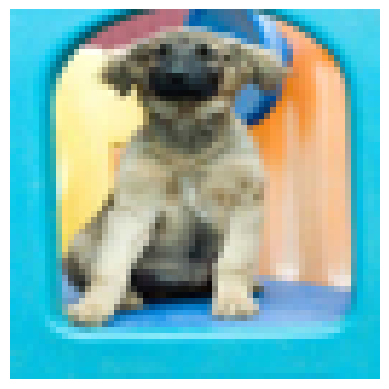

True label: [1]
Predicted label: [[1]]
Predicted probability: [[0.56528748]]


In [ ]:

import matplotlib.pyplot as plt                   #testing on existing dataset#

index = 120

image_for_display = X_test[:, index].reshape(64, 64, 3)
plt.imshow(image_for_display)
plt.axis('off')
plt.show()

single_image = X_test[:, index].reshape(-1,1)
true_label = Y_test[:, index]
print(f"True label: {true_label}")

def predict(X_test, W1, b1, W2, b2):
    Z1 = np.dot(W1, X_test) + b1
    A1 = np.maximum(0,Z1)
    Z2 = np.dot(W2, A1) + b2
    A2 = 1 / (1 + np.exp(-Z2))
    prediction = (A2 > 0.5).astype(int)
    return prediction, A2

pred, prob = predict(single_image, W1, b1, W2, b2)

print(f"Predicted label: {pred}")
print(f"Predicted probability: {prob}")

## 9. Predicting on New, Uploaded Images

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving cat1.jpg to cat1.jpg


In [ ]:
def predict_image(image_path, W1, b1, W2, b2):        #testing on images uplaoded from internet#
    img = Image.open(image_path).convert("RGB")
    img = img.resize((64, 64))

    plt.imshow(img)
    plt.axis("off")
    plt.show()

    x = np.array(img)
    x = x.reshape(-1, 1)
    x = x / 255.0

    prediction, probability = predict(x, W1, b1, W2, b2)

    if prediction[0, 0] == 1:
        print("Prediction: 🐶 Dog")
    else:
        print("Prediction: 🐱 Cat")

    print("Probability:", probability[0, 0])

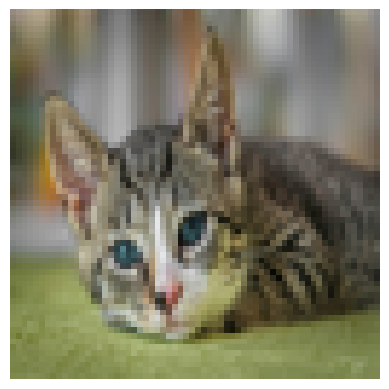

Prediction: 🐱 Cat
Probability: 0.4580359053605488


In [ ]:
predict_image("cat1.jpg",W1,b1,W2,b2)